# Anlyze the Dataset

As we keep each example intact (and not removing any statements) we will load the original dataset and create
our subset by identifying the examples by the text.

Thus we have the subset that we used for our dataset as well as the original dataset.

In [2]:
import gzip
import json
def load_text(filename):
    def smart_open(filename, mode='rt', encoding='utf-8'):
        if filename.endswith('.gz'):
            return gzip.open(filename, mode=mode, encoding=None if 'b' in mode else encoding)
        else:
            return open(filename, mode=mode, encoding=None if 'b' in mode else encoding)
    dataset = set()
    with smart_open(filename, mode='rt', encoding='utf-8') as f:
        for line in f:
            example = json.loads(line)
            dataset.add(example["text"])
    return dataset

our_train_text = load_text("train_dataset.jsonl.gz")
our_val_text = load_text("val_dataset.jsonl.gz")
our_test_text = load_text("test_dataset.jsonl.gz")
our_val_test_text = our_val_text.union(our_test_text)

In [4]:
from datasets import load_dataset
import re

def process_synthie_dataset(dataset):
    """
    Process the dataset to extract triples and text.
    Returns a list of tuples, each containing the text and a list of triples.
    """
    uri_regex = re.compile(r"'uri': '(\w+)'")
    processed_dataset = []
    for row in dataset:
        raw_triples = []
        for triple in row['triplets']:
            match_subj = uri_regex.search(triple['subject'])
            match_pred = uri_regex.search(triple['predicate'])
            match_obj = uri_regex.search(triple['object'])

            if not match_subj or not match_pred or not match_obj:
                print('Error: Could not find URI in triple:', triple)
                continue
            raw_triples.append((match_subj.group(1), match_pred.group(1), match_obj.group(1)))
        processed_dataset.append((row['text'], raw_triples))
    return processed_dataset

original_train = process_synthie_dataset(load_dataset("martinjosifoski/SynthIE", "synthie_code", split="train"))
original_val = process_synthie_dataset(load_dataset("martinjosifoski/SynthIE", "synthie_text", split="validation"))
original_test = process_synthie_dataset(load_dataset("martinjosifoski/SynthIE", "synthie_text", split="test"))
original_val_test = original_val + original_test

/work/shertlin/miniconda3/envs/wikitwo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
def create_our_used_subset(dataset, text_dataset):
    return [example for example in dataset if example[0] in text_dataset]
    
our_subset_train = create_our_used_subset(original_train, our_train_text)
our_subset_val_test = create_our_used_subset(original_val_test, our_val_test_text)

## Distributional Analysis
now we analyze the distributions of our subset and the original dataset.

Since we merged the val and test dataset, we only compare the train and merged val/test datasets.

In [38]:
from collections import Counter
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import pandas as pd

# Avoid scientific notation in DataFrame displays (e.g. 1.815378e+06)
def _fmt_float(x):
    if abs(x - round(x)) < 1e-9 and abs(x) >= 1:
        return f"{x:.0f}"
    return f"{x:.4f}"

pd.set_option("display.float_format", _fmt_float)


def collect_stats(dataset):
    """dataset: list of (text, [(s, p, o), ...])"""
    n_examples = len(dataset)
    triples_per_ex = []
    entities_per_ex = []
    relations_per_ex = []
    rel_counts = Counter()
    ent_counts = Counter()
    n_triples = 0

    for _, triples in dataset:
        triples_per_ex.append(len(triples))
        ents = set()
        rels = set()
        for s, p, o in triples:
            n_triples += 1
            rel_counts[p] += 1
            ent_counts[s] += 1
            ent_counts[o] += 1
            ents.add(s)
            ents.add(o)
            rels.add(p)
        entities_per_ex.append(len(ents))
        relations_per_ex.append(len(rels))

    return {
        "n_examples": n_examples,
        "n_triples": n_triples,
        "n_unique_relations": len(rel_counts),
        "n_unique_entities": len(ent_counts),
        "rel_counts": rel_counts,
        "ent_counts": ent_counts,
        "triples_per_ex": np.array(triples_per_ex),
        "entities_per_ex": np.array(entities_per_ex),
        "relations_per_ex": np.array(relations_per_ex),
    }


stats_orig_train = collect_stats(original_train)
stats_sub_train = collect_stats(our_subset_train)
stats_orig_vt = collect_stats(original_val_test)
stats_sub_vt = collect_stats(our_subset_val_test)

print("Loaded stats for train and val+test (original vs subset).")

Loaded stats for train and val+test (original vs subset).


In [39]:
def macro_comparison(name, orig, sub):
    rows = []
    keys = [
        ("examples", "n_examples"),
        ("triples", "n_triples"),
        ("unique relations", "n_unique_relations"),
        ("unique entities", "n_unique_entities"),
    ]
    for label, key in keys:
        o, s = orig[key], sub[key]
        rows.append({
            "split": name,
            "metric": label,
            "original": o,
            "subset": s,
            "retention_%": 100.0 * s / o if o else float("nan"),
        })
    # mean difficulty proxies
    for label, key in [
        ("mean triples/example", "triples_per_ex"),
        ("mean entities/example", "entities_per_ex"),
        ("mean relations/example", "relations_per_ex"),
    ]:
        o, s = orig[key].mean(), sub[key].mean()
        rows.append({
            "split": name,
            "metric": label,
            "original": round(o, 3),
            "subset": round(s, 3),
            "retention_%": 100.0 * s / o if o else float("nan"),
        })
    return rows


macro_df = pd.DataFrame(
    macro_comparison("train", stats_orig_train, stats_sub_train)
    + macro_comparison("val+test", stats_orig_vt, stats_sub_vt)
)
macro_df

,split,metric,original,subset,retention_%
0,train,examples,1815378,564095,31.0731
1,train,triples,6055911,1428986,23.5965
2,train,unique relations,888,748,84.2342
3,train,unique entities,1806126,746436,41.3280
4,train,mean triples/example,3.3360,2.5330,75.9387
5,train,mean entities/example,4.2890,3.5000,81.5987
6,train,mean relations/example,3.0270,2.2570,74.5544
7,val+test,examples,60286,24499,40.6380
8,val+test,triples,207253,68601,33.1001
9,val+test,unique relations,888,775,87.2748


In [40]:
def survival_table(orig_counts, sub_counts, item_name="item"):
    """Per-item survival = subset_count / original_count; only items in original."""
    rows = []
    for item, o_cnt in orig_counts.items():
        s_cnt = sub_counts.get(item, 0)
        rows.append({
            item_name: item,
            "original": o_cnt,
            "subset": s_cnt,
            "survival": s_cnt / o_cnt if o_cnt else float("nan"),
        })
    df = pd.DataFrame(rows).sort_values("original", ascending=False).reset_index(drop=True)
    return df


def survival_summary(df, label):
    surv = df["survival"]
    totally_lost = (surv == 0).sum()
    severe = ((surv > 0) & (surv < 0.1)).sum()
    return {
        "label": label,
        "n_items_original": len(df),
        "n_items_retained": int((surv > 0).sum()),
        "n_totally_lost": int(totally_lost),
        "n_survival_<10%": int(severe),
        "mean_survival": surv.mean(),
        "median_survival": surv.median(),
        "pct_mass_retained": 100.0 * df["subset"].sum() / df["original"].sum(),
    }


rel_surv_train = survival_table(stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], "relation")
rel_surv_vt = survival_table(stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], "relation")
ent_surv_train = survival_table(stats_orig_train["ent_counts"], stats_sub_train["ent_counts"], "entity")
ent_surv_vt = survival_table(stats_orig_vt["ent_counts"], stats_sub_vt["ent_counts"], "entity")

survival_summary_df = pd.DataFrame([
    survival_summary(rel_surv_train, "relations / train"),
    survival_summary(rel_surv_vt, "relations / val+test"),
    survival_summary(ent_surv_train, "entities / train"),
    survival_summary(ent_surv_vt, "entities / val+test"),
])
survival_summary_df

,label,n_items_original,n_items_retained,n_totally_lost,n_survival_<10%,mean_survival,median_survival,pct_mass_retained
0,relations / train,888,748,140,286,0.1875,0.1267,23.5965
1,relations / val+test,888,775,113,159,0.3306,0.3364,33.1001
2,entities / train,1806126,746436,1059690,13020,0.3421,0.0000,23.5965
3,entities / val+test,121258,57126,64132,230,0.4252,0.0000,33.1001


In [41]:
def counts_to_prob(counts, vocabulary):
    arr = np.array([counts.get(k, 0) for k in vocabulary], dtype=float)
    total = arr.sum()
    if total == 0:
        return arr
    return arr / total


def distribution_distance(orig_counts, sub_counts, label):
    vocab = sorted(set(orig_counts) | set(sub_counts))
    p = counts_to_prob(orig_counts, vocab)
    q = counts_to_prob(sub_counts, vocab)
    js = float(jensenshannon(p, q, base=2))  # in [0, 1] with base=2

    # Spearman on ranks over items that appear in original
    shared = sorted(orig_counts.keys())
    o_rank = [orig_counts[k] for k in shared]
    s_rank = [sub_counts.get(k, 0) for k in shared]
    if len(shared) >= 2:
        spearman_rho, spearman_p = spearmanr(o_rank, s_rank)
    else:
        spearman_rho, spearman_p = float("nan"), float("nan")

    # total variation distance
    tv = 0.5 * np.abs(p - q).sum()
    return {
        "label": label,
        "JS_divergence": js,
        "TV_distance": float(tv),
        "Spearman_rho": float(spearman_rho),
        "Spearman_p": float(spearman_p),
        "vocab_size_union": len(vocab),
    }


dist_df = pd.DataFrame([
    distribution_distance(stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], "relations / train"),
    distribution_distance(stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], "relations / val+test"),
    distribution_distance(stats_orig_train["ent_counts"], stats_sub_train["ent_counts"], "entities / train"),
    distribution_distance(stats_orig_vt["ent_counts"], stats_sub_vt["ent_counts"], "entities / val+test"),
])
dist_df

,label,JS_divergence,TV_distance,Spearman_rho,Spearman_p,vocab_size_union
0,relations / train,0.4118,0.3361,0.4976,0.0000,888
1,relations / val+test,0.3612,0.2899,0.5940,0.0000,888
2,entities / train,0.6012,0.5508,0.1146,0.0000,1806126
3,entities / val+test,0.5986,0.5512,0.1282,0.0000,121258


In [42]:
def topk_share_comparison(orig_counts, sub_counts, k=15, item_name="relation"):
    """Side-by-side top-k by original frequency, with share before/after."""
    o_total = sum(orig_counts.values())
    s_total = sum(sub_counts.values())
    top = [item for item, _ in orig_counts.most_common(k)]
    rows = []
    for item in top:
        o = orig_counts[item]
        s = sub_counts.get(item, 0)
        rows.append({
            item_name: item,
            "orig_count": o,
            "orig_share_%": 100.0 * o / o_total,
            "sub_count": s,
            "sub_share_%": 100.0 * s / s_total if s_total else 0.0,
            "survival": s / o if o else float("nan"),
            "share_delta_pp": (100.0 * s / s_total if s_total else 0.0) - 100.0 * o / o_total,
        })
    return pd.DataFrame(rows)


print("=== Top-15 relations by original frequency: TRAIN ===")
display(topk_share_comparison(stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], k=15, item_name="relation"))

print("=== Top-15 relations by original frequency: VAL+TEST ===")
display(topk_share_comparison(stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], k=15, item_name="relation"))

=== Top-15 relations by original frequency: TRAIN ===


,relation,orig_count,orig_share_%,sub_count,sub_share_%,survival,share_delta_pp
0,P31,500340,8.2620,142778,9.9916,0.2854,1.7295
1,P17,356761,5.8911,142483,9.9709,0.3994,4.0798
2,P131,248957,4.1110,134504,9.4125,0.5403,5.3016
3,P27,148392,2.4504,29041,2.0323,0.1957,-0.4181
4,P106,141753,2.3407,13,0.0009,0.0001,-2.3398
5,P641,138462,2.2864,1164,0.0815,0.0084,-2.2049
6,P19,123891,2.0458,28825,2.0172,0.2327,-0.0286
7,P279,110550,1.8255,4710,0.3296,0.0426,-1.4959
8,P421,91785,1.5156,64303,4.4999,0.7006,2.9843
9,P54,90438,1.4934,26891,1.8818,0.2973,0.3884


=== Top-15 relations by original frequency: VAL+TEST ===


,relation,orig_count,orig_share_%,sub_count,sub_share_%,survival,share_delta_pp
0,P31,15602,7.5280,5876,8.5655,0.3766,1.0375
1,P17,10630,5.1290,5162,7.5247,0.4856,2.3957
2,P131,7450,3.5946,4759,6.9372,0.6388,3.3426
3,P279,4201,2.0270,151,0.2201,0.0359,-1.8069
4,P27,4174,2.0140,969,1.4125,0.2322,-0.6014
5,P106,3979,1.9199,20,0.0292,0.0050,-1.8907
6,P641,3850,1.8576,30,0.0437,0.0078,-1.8139
7,P19,3572,1.7235,969,1.4125,0.2713,-0.3110
8,P421,2633,1.2704,1953,2.8469,0.7417,1.5765
9,P1412,2570,1.2400,2,0.0029,0.0008,-1.2371


In [43]:
def frequency_bucket_retention(orig_counts, sub_counts, item_name="item"):
    """Head / torso / tail by original frequency terciles of unique items (by count mass ranks)."""
    items = sorted(orig_counts.items(), key=lambda x: -x[1])
    n = len(items)
    if n == 0:
        return pd.DataFrame()

    # bucket by rank: top 10% head, next 40% torso, bottom 50% tail
    head_cut = max(1, int(0.1 * n))
    torso_cut = max(head_cut + 1, int(0.5 * n))
    buckets = {
        "head (top 10% items)": items[:head_cut],
        "torso (next 40%)": items[head_cut:torso_cut],
        "tail (bottom 50%)": items[torso_cut:],
    }
    rows = []
    for bname, blist in buckets.items():
        o_items = len(blist)
        s_items = sum(1 for k, _ in blist if sub_counts.get(k, 0) > 0)
        o_mass = sum(c for _, c in blist)
        s_mass = sum(sub_counts.get(k, 0) for k, _ in blist)
        rows.append({
            "bucket": bname,
            f"n_{item_name}_orig": o_items,
            f"n_{item_name}_retained": s_items,
            "item_retention_%": 100.0 * s_items / o_items if o_items else float("nan"),
            "orig_mass": o_mass,
            "sub_mass": s_mass,
            "mass_retention_%": 100.0 * s_mass / o_mass if o_mass else float("nan"),
        })
    return pd.DataFrame(rows)


print("=== Relation frequency-bucket retention: TRAIN ===")
display(frequency_bucket_retention(stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], "relation"))
print("=== Relation frequency-bucket retention: VAL+TEST ===")
display(frequency_bucket_retention(stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], "relation"))
print("=== Entity frequency-bucket retention: TRAIN ===")
display(frequency_bucket_retention(stats_orig_train["ent_counts"], stats_sub_train["ent_counts"], "entity"))
print("=== Entity frequency-bucket retention: VAL+TEST ===")
display(frequency_bucket_retention(stats_orig_vt["ent_counts"], stats_sub_vt["ent_counts"], "entity"))

=== Relation frequency-bucket retention: TRAIN ===


,bucket,n_relation_orig,n_relation_retained,item_retention_%,orig_mass,sub_mass,mass_retention_%
0,head (top 10% items),88,88,100,4103056,1053208,25.6689
1,torso (next 40%),356,322,90.4494,1505500,293918,19.5229
2,tail (bottom 50%),444,338,76.1261,447355,81860,18.2987


=== Relation frequency-bucket retention: VAL+TEST ===


,bucket,n_relation_orig,n_relation_retained,item_retention_%,orig_mass,sub_mass,mass_retention_%
0,head (top 10% items),88,88,100,128296,42097,32.8124
1,torso (next 40%),356,330,92.6966,58122,19502,33.5536
2,tail (bottom 50%),444,357,80.4054,20835,7002,33.6069


=== Entity frequency-bucket retention: TRAIN ===


,bucket,n_entity_orig,n_entity_retained,item_retention_%,orig_mass,sub_mass,mass_retention_%
0,head (top 10% items),180612,115524,63.9625,7954820,1594171,20.0403
1,torso (next 40%),722451,231762,32.0800,2716924,679084,24.9946
2,tail (bottom 50%),903063,399150,44.1996,1440078,584717,40.6031


=== Entity frequency-bucket retention: VAL+TEST ===


,bucket,n_entity_orig,n_entity_retained,item_retention_%,orig_mass,sub_mass,mass_retention_%
0,head (top 10% items),12125,5999,49.4763,196953,49998,25.3858
1,torso (next 40%),48504,20740,42.7594,147697,52810,35.7556
2,tail (bottom 50%),60629,30387,50.1196,69856,34394,49.2356


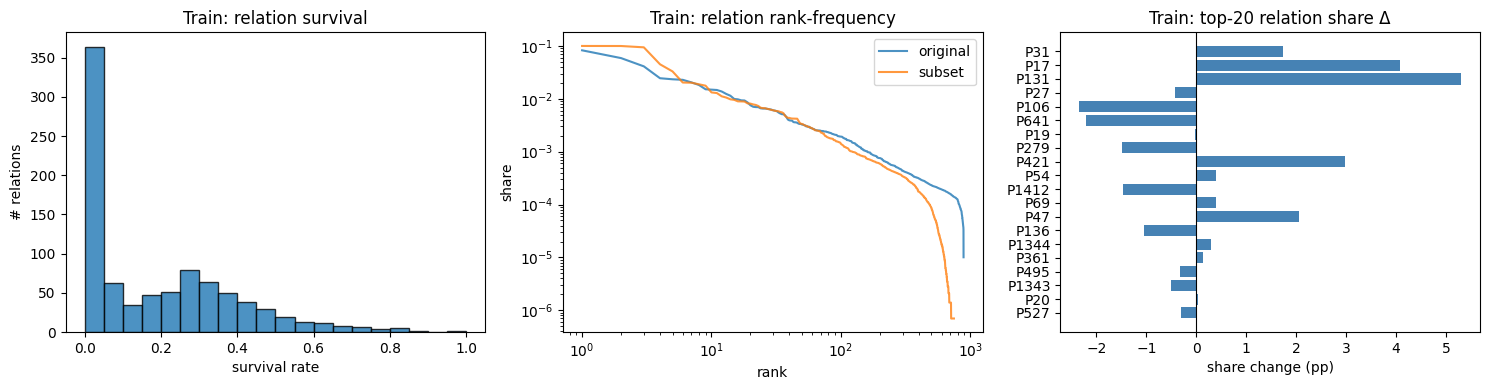

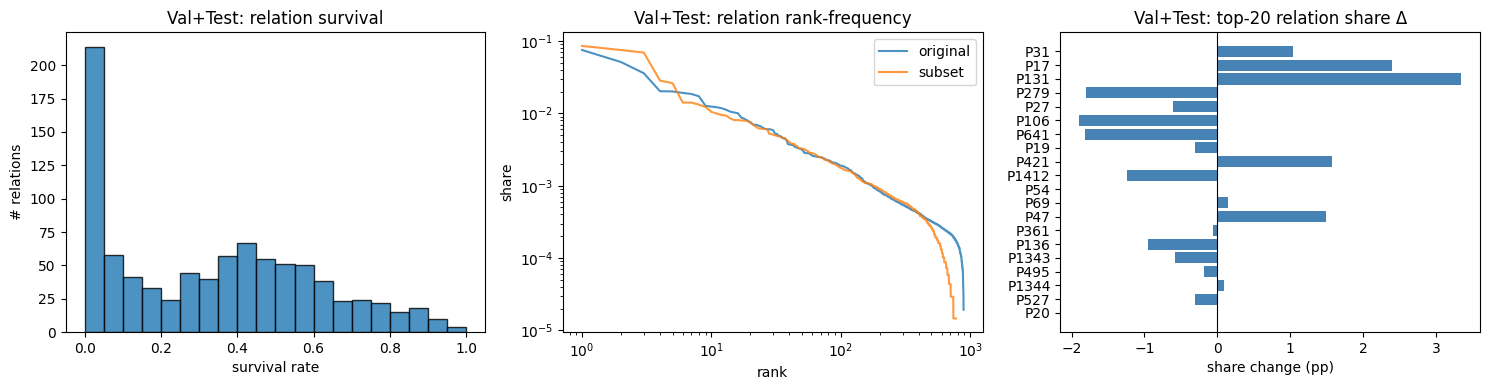

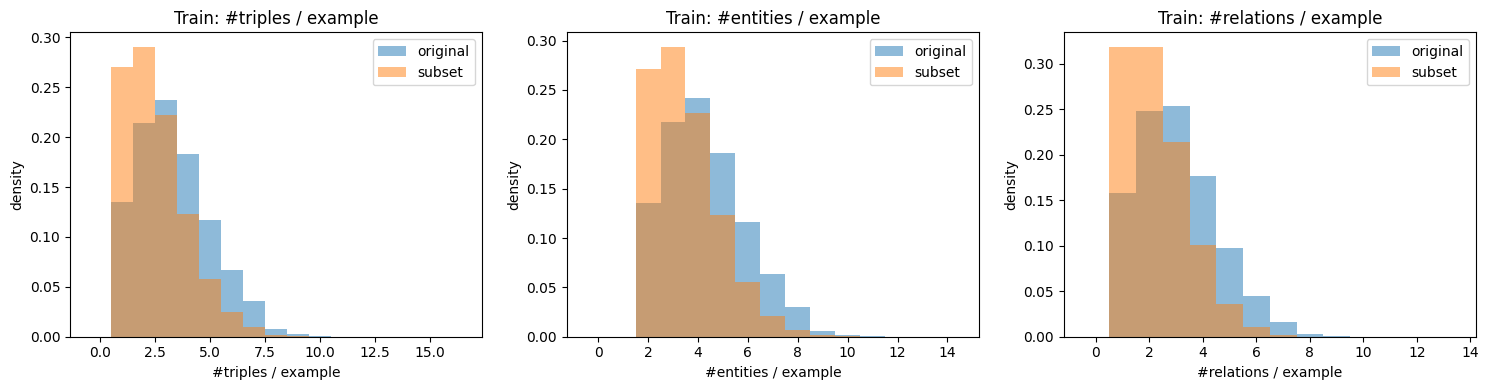

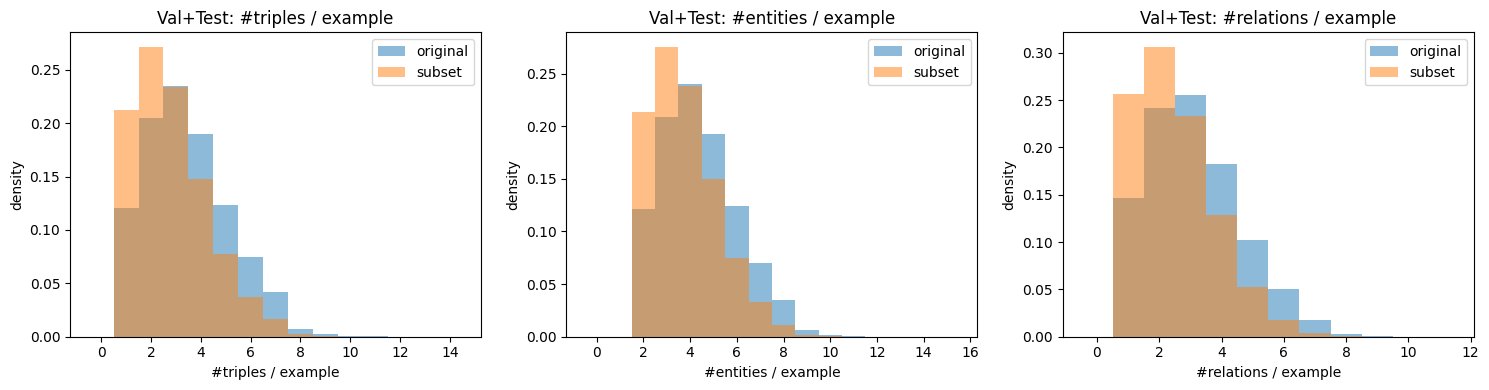

In [44]:
def plot_survival_and_rankfreq(rel_surv, orig_counts, sub_counts, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1) survival histogram
    axes[0].hist(rel_surv["survival"], bins=20, range=(0, 1), edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("survival rate")
    axes[0].set_ylabel("# relations")
    axes[0].set_title(f"{title_prefix}: relation survival")

    # 2) rank-frequency (log-log), shares
    def ranked_shares(counts):
        vals = np.array(sorted(counts.values(), reverse=True), dtype=float)
        return vals / vals.sum() if vals.sum() else vals

    o_share = ranked_shares(orig_counts)
    s_share = ranked_shares(sub_counts)
    axes[1].loglog(np.arange(1, len(o_share) + 1), o_share, label="original", alpha=0.8)
    axes[1].loglog(np.arange(1, len(s_share) + 1), s_share, label="subset", alpha=0.8)
    axes[1].set_xlabel("rank")
    axes[1].set_ylabel("share")
    axes[1].set_title(f"{title_prefix}: relation rank-frequency")
    axes[1].legend()

    # 3) triples-per-example histogram (passed separately below — placeholder filled by caller via fig)
    axes[2].axis("off")
    plt.tight_layout()
    return fig, axes


def plot_difficulty(orig_stats, sub_stats, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, label in zip(
        axes,
        ["triples_per_ex", "entities_per_ex", "relations_per_ex"],
        ["#triples / example", "#entities / example", "#relations / example"],
    ):
        o = orig_stats[key]
        s = sub_stats[key]
        vmax = int(max(o.max(), s.max()))
        bins = np.arange(0, vmax + 2) - 0.5
        ax.hist(o, bins=bins, density=True, alpha=0.5, label="original")
        ax.hist(s, bins=bins, density=True, alpha=0.5, label="subset")
        ax.set_xlabel(label)
        ax.set_ylabel("density")
        ax.set_title(f"{title_prefix}: {label}")
        ax.legend()
    plt.tight_layout()
    return fig


fig, axes = plot_survival_and_rankfreq(
    rel_surv_train, stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], "Train"
)
# fill third panel: share delta for top-20 relations
top20 = topk_share_comparison(stats_orig_train["rel_counts"], stats_sub_train["rel_counts"], k=20)
axes[2].barh(top20["relation"][::-1], top20["share_delta_pp"][::-1], color="steelblue")
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("share change (pp)")
axes[2].set_title("Train: top-20 relation share Δ")
axes[2].axis("on")
plt.tight_layout()
plt.show()

fig, axes = plot_survival_and_rankfreq(
    rel_surv_vt, stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], "Val+Test"
)
top20 = topk_share_comparison(stats_orig_vt["rel_counts"], stats_sub_vt["rel_counts"], k=20)
axes[2].barh(top20["relation"][::-1], top20["share_delta_pp"][::-1], color="steelblue")
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("share change (pp)")
axes[2].set_title("Val+Test: top-20 relation share Δ")
axes[2].axis("on")
plt.tight_layout()
plt.show()

plot_difficulty(stats_orig_train, stats_sub_train, "Train")
plt.show()
plot_difficulty(stats_orig_vt, stats_sub_vt, "Val+Test")
plt.show()

In [45]:
# Relations that are systematically lost or heavily under-retained
def lost_and_underretained(surv_df, item_col, min_orig=50, survival_thresh=0.1, top_n=20):
    lost = surv_df[surv_df["survival"] == 0].sort_values("original", ascending=False)
    under = surv_df[
        (surv_df["survival"] > 0)
        & (surv_df["survival"] < survival_thresh)
        & (surv_df["original"] >= min_orig)
    ].sort_values("original", ascending=False)
    print(f"Totally lost {item_col}s (top {top_n} by original count):")
    display(lost.head(top_n))
    print(f"Heavily under-retained {item_col}s (survival < {survival_thresh}, orig >= {min_orig}, top {top_n}):")
    display(under.head(top_n))
    return lost, under


print("========== TRAIN ==========")
lost_rel_train, under_rel_train = lost_and_underretained(rel_surv_train, "relation")

print("========== VAL+TEST ==========")
lost_rel_vt, under_rel_vt = lost_and_underretained(rel_surv_vt, "relation")

========== TRAIN ==========
Totally lost relations (top 20 by original count):


,relation,original,subset,survival
152,P286,6316,0,0.0000
153,P59,6313,0,0.0000
188,P915,4924,0,0.0000
194,P485,4642,0,0.0000
202,P611,4521,0,0.0000
204,P414,4468,0,0.0000
211,P479,4205,0,0.0000
245,P200,3402,0,0.0000
265,P3161,3125,0,0.0000
282,P2894,2897,0,0.0000


Heavily under-retained relations (survival < 0.1, orig >= 50, top 20):


,relation,original,subset,survival
4,P106,141753,13,0.0001
5,P641,138462,1164,0.0084
7,P279,110550,4710,0.0426
10,P1412,88966,147,0.0017
13,P136,69261,1406,0.0203
25,P407,39615,148,0.0037
37,P105,27188,370,0.0136
40,P364,23479,134,0.0057
41,P171,23379,2224,0.0951
42,P39,21975,5,0.0002


========== VAL+TEST ==========
Totally lost relations (top 20 by original count):


,relation,original,subset,survival
105,P462,382,0,0.0000
118,P6216,339,0,0.0000
144,P780,262,0,0.0000
146,P1995,259,0,0.0000
148,P1196,241,0,0.0000
152,P3095,237,0,0.0000
207,P682,165,0,0.0000
217,P2989,156,0,0.0000
226,P412,150,0,0.0000
232,P1399,145,0,0.0000


Heavily under-retained relations (survival < 0.1, orig >= 50, top 20):


,relation,original,subset,survival
3,P279,4201,151,0.0359
5,P106,3979,20,0.0050
6,P641,3850,30,0.0078
9,P1412,2570,2,0.0008
14,P136,2132,54,0.0253
23,P407,1375,11,0.0080
35,P105,934,14,0.0150
38,P171,778,77,0.0990
43,P364,714,4,0.0056
47,P366,675,14,0.0207


## Text / sentence distributional analysis

Compare surface-form text statistics between original and subset (train and val+test): example counts, characters, words, sentences, and length distributions.

In [46]:
import re

_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")
_WORD_SPLIT = re.compile(r"\b\w+\b", re.UNICODE)


def split_sentences(text):
    text = text.strip()
    if not text:
        return []
    parts = _SENT_SPLIT.split(text)
    return [p for p in parts if p.strip()]


def collect_text_stats(dataset):
    """dataset: list of (text, triples)."""
    n_examples = len(dataset)
    chars_per_ex = []
    words_per_ex = []
    sents_per_ex = []
    words_per_sent = []
    chars_per_sent = []

    total_chars = 0
    total_words = 0
    total_sents = 0

    for text, _ in dataset:
        words = _WORD_SPLIT.findall(text)
        sents = split_sentences(text)
        n_chars = len(text)
        n_words = len(words)
        n_sents = max(len(sents), 1)  # treat empty-split text as 1 sentence unit

        chars_per_ex.append(n_chars)
        words_per_ex.append(n_words)
        sents_per_ex.append(len(sents) if sents else 1)

        total_chars += n_chars
        total_words += n_words
        total_sents += len(sents) if sents else 1

        for sent in (sents if sents else [text]):
            sw = _WORD_SPLIT.findall(sent)
            words_per_sent.append(len(sw))
            chars_per_sent.append(len(sent))

    return {
        "n_examples": n_examples,
        "n_chars": total_chars,
        "n_words": total_words,
        "n_sentences": total_sents,
        "chars_per_ex": np.array(chars_per_ex, dtype=float),
        "words_per_ex": np.array(words_per_ex, dtype=float),
        "sents_per_ex": np.array(sents_per_ex, dtype=float),
        "words_per_sent": np.array(words_per_sent, dtype=float),
        "chars_per_sent": np.array(chars_per_sent, dtype=float),
    }


text_orig_train = collect_text_stats(original_train)
text_sub_train = collect_text_stats(our_subset_train)
text_orig_vt = collect_text_stats(original_val_test)
text_sub_vt = collect_text_stats(our_subset_val_test)

print("Collected text stats for train and val+test.")

Collected text stats for train and val+test.


In [47]:
def _pct(a, b):
    return 100.0 * a / b if b else float("nan")


def text_macro_comparison(name, orig, sub):
    rows = []
    for label, key in [
        ("examples", "n_examples"),
        ("total characters", "n_chars"),
        ("total words", "n_words"),
        ("total sentences", "n_sentences"),
    ]:
        o, s = orig[key], sub[key]
        rows.append({
            "split": name,
            "metric": label,
            "original": o,
            "subset": s,
            "retention_%": _pct(s, o),
        })

    for label, key in [
        ("mean chars / example", "chars_per_ex"),
        ("mean words / example", "words_per_ex"),
        ("mean sentences / example", "sents_per_ex"),
        ("mean words / sentence", "words_per_sent"),
        ("mean chars / sentence", "chars_per_sent"),
        ("median words / example", "words_per_ex"),
        ("median words / sentence", "words_per_sent"),
    ]:
        reducer = np.median if label.startswith("median") else np.mean
        o, s = float(reducer(orig[key])), float(reducer(sub[key]))
        rows.append({
            "split": name,
            "metric": label,
            "original": round(o, 3),
            "subset": round(s, 3),
            "retention_%": _pct(s, o),
        })
    return rows


text_macro_df = pd.DataFrame(
    text_macro_comparison("train", text_orig_train, text_sub_train)
    + text_macro_comparison("val+test", text_orig_vt, text_sub_vt)
)
text_macro_df

,split,metric,original,subset,retention_%
0,train,examples,1815378,564095,31.0731
1,train,total characters,224731967,58869809,26.1956
2,train,total words,38064486,9978707,26.2153
3,train,total sentences,3000509,807257,26.9040
4,train,mean chars / example,123.7930,104.3620,84.3029
5,train,mean words / example,20.9680,17.6900,84.3663
6,train,mean sentences / example,1.6530,1.4310,86.5828
7,train,mean words / sentence,12.6860,12.3610,97.4400
8,train,mean chars / sentence,74.5030,72.6240,97.4789
9,train,median words / example,17,14,82.3529


In [48]:
def text_distribution_distance(orig_arr, sub_arr, label, n_bins=40):
    """Compare two length distributions via histogram JS + mean/std shift."""
    lo = float(min(orig_arr.min(), sub_arr.min()))
    hi = float(max(orig_arr.max(), sub_arr.max()))
    if hi <= lo:
        hi = lo + 1.0
    bins = np.linspace(lo, hi, n_bins + 1)
    p, _ = np.histogram(orig_arr, bins=bins, density=False)
    q, _ = np.histogram(sub_arr, bins=bins, density=False)
    p = p.astype(float)
    q = q.astype(float)
    p = p / p.sum() if p.sum() else p
    q = q / q.sum() if q.sum() else q
    js = float(jensenshannon(p, q, base=2))
    tv = float(0.5 * np.abs(p - q).sum())
    return {
        "label": label,
        "JS_divergence": js,
        "TV_distance": tv,
        "orig_mean": float(orig_arr.mean()),
        "sub_mean": float(sub_arr.mean()),
        "mean_ratio": float(sub_arr.mean() / orig_arr.mean()) if orig_arr.mean() else float("nan"),
        "orig_std": float(orig_arr.std()),
        "sub_std": float(sub_arr.std()),
    }


text_dist_df = pd.DataFrame([
    text_distribution_distance(text_orig_train["words_per_ex"], text_sub_train["words_per_ex"], "words/example / train"),
    text_distribution_distance(text_orig_vt["words_per_ex"], text_sub_vt["words_per_ex"], "words/example / val+test"),
    text_distribution_distance(text_orig_train["sents_per_ex"], text_sub_train["sents_per_ex"], "sentences/example / train"),
    text_distribution_distance(text_orig_vt["sents_per_ex"], text_sub_vt["sents_per_ex"], "sentences/example / val+test"),
    text_distribution_distance(text_orig_train["words_per_sent"], text_sub_train["words_per_sent"], "words/sentence / train"),
    text_distribution_distance(text_orig_vt["words_per_sent"], text_sub_vt["words_per_sent"], "words/sentence / val+test"),
    text_distribution_distance(text_orig_train["chars_per_ex"], text_sub_train["chars_per_ex"], "chars/example / train"),
    text_distribution_distance(text_orig_vt["chars_per_ex"], text_sub_vt["chars_per_ex"], "chars/example / val+test"),
])
text_dist_df

,label,JS_divergence,TV_distance,orig_mean,sub_mean,mean_ratio,orig_std,sub_std
0,words/example / train,0.1138,0.1148,20.9678,17.6898,0.8437,16.3572,12.9988
1,words/example / val+test,0.1176,0.1148,24.5528,21.5056,0.8759,11.9603,11.0199
2,sentences/example / train,0.1077,0.1138,1.6528,1.4311,0.8658,1.0455,0.8298
3,sentences/example / val+test,0.1271,0.1422,1.7089,1.4887,0.8711,0.8316,0.7355
4,words/sentence / train,0.0344,0.0330,12.6860,12.3613,0.9744,6.1508,5.8151
5,words/sentence / val+test,0.0336,0.0295,14.3677,14.4462,1.0055,6.0769,6.2833
6,chars/example / train,0.1128,0.1101,123.7935,104.3615,0.8430,96.8656,76.6521
7,chars/example / val+test,0.1150,0.1155,145.9030,128.1177,0.8781,71.6812,66.0603


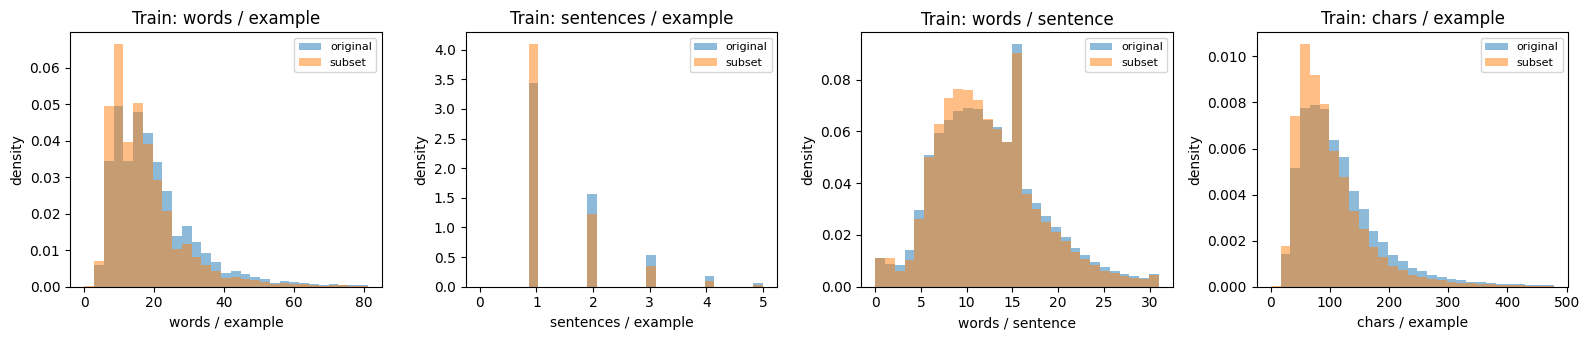

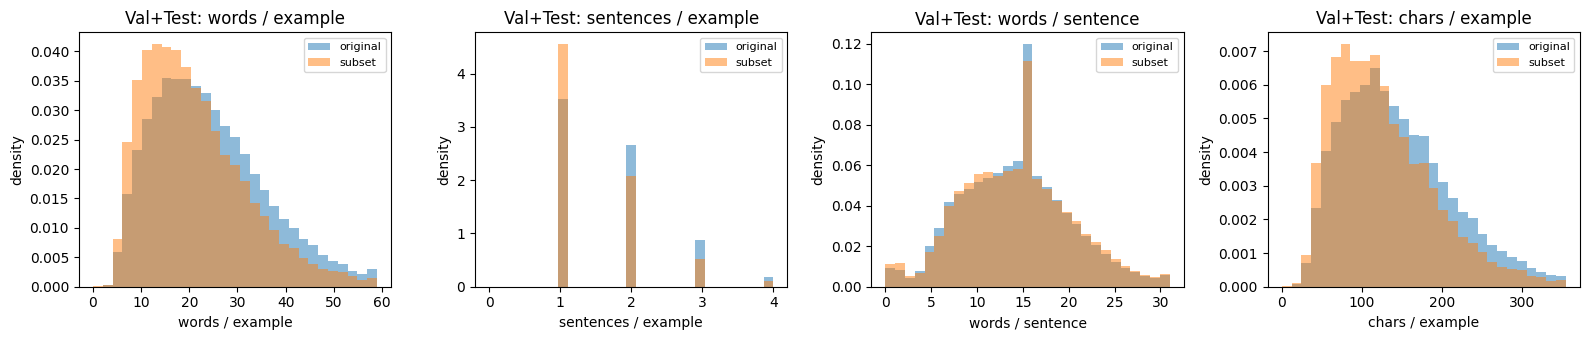

=== Length-bucket retention (words/example): TRAIN ===


,words/example bucket,original_examples,subset_examples,retention_%,orig_share_%,sub_share_%
0,"[0, 25)",1337252,464025,34.6999,73.6625,82.2601
1,"[25, 50)",400890,86025,21.4585,22.0830,15.2501
2,"[50, 100)",65133,12372,18.9950,3.5878,2.1932
3,"[100, 200)",10893,1531,14.0549,0.6000,0.2714
4,"[200, ∞)",1210,142,11.7355,0.0667,0.0252


=== Length-bucket retention (words/example): VAL+TEST ===


,words/example bucket,original_examples,subset_examples,retention_%,orig_share_%,sub_share_%
0,"[0, 25)",33862,16509,48.7538,56.1689,67.3864
1,"[25, 50)",24144,7428,30.7654,40.0491,30.3196
2,"[50, 100)",2280,562,24.6491,3.7820,2.2940
3,"[100, 200)",0,0,NaN,0.0000,0.0000
4,"[200, ∞)",0,0,NaN,0.0000,0.0000


In [49]:
def plot_text_length_distributions(orig, sub, title_prefix):
    specs = [
        ("words_per_ex", "words / example"),
        ("sents_per_ex", "sentences / example"),
        ("words_per_sent", "words / sentence"),
        ("chars_per_ex", "chars / example"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for ax, (key, label) in zip(axes, specs):
        o, s = orig[key], sub[key]
        # shared bins; cap extreme tail for readability at 99th percentile
        hi = np.percentile(np.concatenate([o, s]), 99)
        bins = np.linspace(0, max(hi, 1), 30)
        ax.hist(o, bins=bins, density=True, alpha=0.5, label="original")
        ax.hist(s, bins=bins, density=True, alpha=0.5, label="subset")
        ax.set_xlabel(label)
        ax.set_ylabel("density")
        ax.set_title(f"{title_prefix}: {label}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


plot_text_length_distributions(text_orig_train, text_sub_train, "Train")
plt.show()
plot_text_length_distributions(text_orig_vt, text_sub_vt, "Val+Test")
plt.show()


# Length-bucket retention: are short/long texts differentially removed?
def length_bucket_retention(orig, sub, key="words_per_ex", edges=(0, 25, 50, 100, 200, 10**9)):
    o = orig[key]
    s = sub[key]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        o_mask = (o >= lo) & (o < hi)
        s_mask = (s >= lo) & (s < hi)
        o_n = int(o_mask.sum())
        s_n = int(s_mask.sum())
        rows.append({
            "words/example bucket": f"[{lo}, {hi})" if hi < 10**9 else f"[{lo}, ∞)",
            "original_examples": o_n,
            "subset_examples": s_n,
            "retention_%": _pct(s_n, o_n),
            "orig_share_%": _pct(o_n, len(o)),
            "sub_share_%": _pct(s_n, len(s)),
        })
    return pd.DataFrame(rows)


print("=== Length-bucket retention (words/example): TRAIN ===")
display(length_bucket_retention(text_orig_train, text_sub_train))
print("=== Length-bucket retention (words/example): VAL+TEST ===")
display(length_bucket_retention(text_orig_vt, text_sub_vt))